# LSH — Locality Sensitive Hashing

### Обзор

Locality Sensitive Hashing - семейство методов приближённого поиска ближайших соседей в высокоразмерных пространствах. В отличие от обычной хеш-функции, которая стремится равномерно распределить данные по корзинам и заведомо разносит даже близкие точки, LSH делает противоположное: похожие объекты с большой вероятностью попадают в одну корзину, а непохожие — в разные. Благодаря этому на этапе запроса достаточно проверить только ту корзину, в которую попал запрос, а не весь индекс.

LSH позволяет бороться с так называемым «проклятием размерности». В пространствах с десятками тысяч признаков точные структуры данных вроде kd-деревьев деградируют до линейного перебора, потому что объёмы шаров и кубов перестают давать осмысленную геометрическую сегментацию. LSH сознательно отказывается от точности — найденный сосед является приближённым и возвращается с некоторой вероятностью - но платит за это сублинейным временем запроса.

Расшифровка названия<br>
- Hashing - это построение уникального "отпечатка" объекта, который позволяет быстро сравнивать сложные объекты<br>
- Locality = свйоство близости объектов<br>
- Locality sensitive хэширование - это хэширование, зависящее от расстояния между объектами. Разные объекты должны по-прежнему получать разные хэши, но похожие могут и должны получать один хэш. На этой фиче и построен метод.

Применяется для поиска нечетких дубликатов в множествах (near duplicate detection). Для поиска полных дубликатов достаточно классических алгоритмов fingerprinting

Fingerprint документа, получаемый как результат хэширования, в литературе называют сигнатурой

### История

Идея в её современном виде появилась в работе (1998) [P. Indyk и R. Motwani «Approximate Nearest Neighbors: Towards Removing the Curse of Dimensionality»](https://graphics.stanford.edu/courses/cs468-06-fall/Papers/06%20indyk%20motwani%20-%20stoc98.pdf). Авторы вводят понятийный аппарат и доказывают основные свойства подхода. Там же они описали первый конструктивный пример — bit sampling для метрики Хэмминга

До этого ускорение достигалось только за счет препроцессинга датасетов, в частности построения пространственных индексов типа kd-tree

В 1997–2000 годах A. Broder, работавший в AltaVista, разработал MinHash для оценки сходства Жаккара при поиске почти-дубликатов веб-страниц; впоследствии это было осознано как частный случай LSH-конструкции

В 2002 году M. Charikar предложил SimHash — LSH для косинусной близости через случайные гиперплоскости, опираясь на классический результат Гёмана–Уильямсона о round-схемах для MAX-CUT.

В 2004 году M. Datar, N. Immorlica, P. Indyk и V. S. Mirrokni построили LSH-семейство для метрики $L_p$ при $p \in (0, 2]$ на базе p-устойчивых распределений. Эта конструкция стала стандартом для евклидовой и манхэттенской близости.

Дальнейшее развитие включает Multi-probe LSH (Lv et al., 2007), сокращающий число таблиц за счёт исследования соседних корзин; LSH Forest (Bawa, Condie, Ganesan, 2005); и data-dependent / spherical LSH (Andoni, Indyk, Laarhoven, Razenshteyn, 2014–2015), достигающие оптимальной показательной константы. С конца 2010-х LSH в продакшене постепенно теснится графовыми методами (HNSW) и обучаемыми хешами, но остаётся базовым теоретическим инструментом.

### Постановка задачи

Дано метрическое пространство $(X, d)$ и база $P \in X$ из n точек. Для запроса q ∈ X нужно найти ближайшую точку $p \in P$, минимизирующую $d(q, p)$. В высокой размерности точная задача дорога, поэтому рассматривают её приближённый вариант — $(R, c)$-NN, где $c > 1$:

- если в датасете P существует точка $p$ с $d(q, p) \leqslant R$, алгоритм должен вернуть какую-нибудь точку $p \in P$ с $d(q, p) \leq cR$
- если такой точки нет, алгоритм может вернуть «ничего» или произвольную точку.

Здесь $R$ — радиус интереса, c — допустимое раздутие. Полная задача NN сводится к серии $(R, cR)$-структур для геометрически растущих $R$, ценой логарифмического множителя.

### Формальное определение

ывается $(R, cR, p₁, p₂)$-чувствительным, если для любых $x, y \in X$ выполняется

- если $d(x, y) \leq R$, то $\mathbb{P}_{h \in H} [ h(x) = h(y) ] \geqslant p_1$
- если $d(x, y) \geq cR$, то $\mathbb{P}_{h \in H} [ h(x) = h(y) ] \leqslant p_2$

Семейство полезно при $p_1 > p_2$. Вероятность берётся по случайному выбору $h из H$, то есть по случайным параметрам конструкции (перестановке, гиперплоскости, проекции).

Условие на $p_1$ задает требование <u>полноты</u>: дубликаты должны срабатывать в большинстве случаев. Но в этом случае нужно ещё ограничение с другой стороны, чтобы точность не падала, поэтому ввели $p_2$: не-дубликаты не должны срабатывать. При этом оставили зазор $[R,cR]$: от серой зоны ничего не требуем.

Ключевая характеристика семейства — показатель соотношения вероятностей

$ρ = \frac{log(1 / p_1)}{log(1 / p_2)}$

Чем меньше $ρ$, тем лучше алгоритм отделяет «близкие vs далёкие» (sharp separartion) и тем он эффективнее. Для всех известных LSH-семейств $ρ < 1$, и именно ρ определяет асимптотику: вычислительная сложность $O(n^\rho)$

### Интерпретация

Локальная чувствительность означает, что вероятность коллизии монотонно зависит от расстояния. Если положить $p(d) = Pr[ h(x) = h(y) | d(x, y) = d ]$, то $p(·)$ — невозрастающая функция: чем дальше точки, тем реже они попадают в одну корзину.

Хеш-таблица, построенная на такой функции, играет роль грубого пространственного индекса. На запросе $q$ вычисляется $h(q)$ и просматривается только одна корзина. С вероятностью не ниже $p₁$ истинный сосед окажется в той же корзине; «далёкие» точки, по случайности попавшие туда же, дают ложные срабатывания, число которых ограничено через $p₂$

Одиночная функция почти всегда даёт слишком слабый сигнал — $p₁$ редко близка к единице, а $p₂$ редко близка к нулю. Поэтому из одной функции собирают композицию.

### Amplification

Предположим, мы выбрали пороги R и cR, а также некоторую аппроксимирующую модель, например, MinHash. Тогда вероятности $p_1$ и $p_2$ однозначно определяются этой моделью. Проблема - это не гитко. Их можно регулировать, объединяя в ансабли

Такая техника называется __banding__ или __amplification__. Выглядит как пост-процессинг с разделением полученного битового вектора на независимые субвектора и их объединение в коньюнкцию (OR). Подход часто описывается просто как стандартная часть LSH

*В существующих методах отдельные биты хэша вычисляются независимо, не только "между" хэш-функциями $h_1(x), h_2(x) ...$, но и в рамках каждой хэш функции $h_i(x)$. Это необходимое условие для более быстрой сходимости метода. Поэтому на практике не важно, вычисляем мы по-одной $h_i(x)$ или один раз посчитать большой набор битов, потом нарезаем посчитанные биты на "полосы" (bands)

Если мы считаем, что коллизия происходит при совпадении всех бит (AND логика), то её вероятность $P_c(r) = p^k(r)$. То есть новая LSH-модель выглядит как $(R, cR, p_1^k, p_2^k)$. Видно, что <u>обе</u> вероятности падают относительно изначальных $p_1$ и $p_2$ (при этом $p_2$ — значительно быстрее). Таким образом мы растим точность (меньше ложных коллизий, только самые очевидные), но роняем полноту

Если же мы делаем коллизию при совпадении хотя бы одного бита (OR логика), то обе вероятности наоборот растут. Таким образом мы растим recall, но роняем precision.

Banding предполагает совмещённую AND-OR схему — k функций внутри одной хэш таблицы и L таких таблиц. Мы фиксируем коллизию, если хотя бы в одной таблице вопади все k хэшей. То есть получаем семейство $(R, cR, 1 − (1 − p₁^k)^L, 1 − (1 − p₂^k)^L)$ 

Работает такая трансформация благодаря разному поведению степенных функций, степень при k быстрее растет в зоне ближе к нулю, а степень L быстрее растет ближе к единице. Получается, мы разводим вероятности по краям.

В итоге у LSH модели два гиперпараметра: 
- размернрость хэша $k$
- кол-во хэшей $L$

Если нарисуем, то вероятность коллизии зависит от R как s-curve.

Рост k => 
Рост L => 

PS при амплификации мы ничего не говорим про архитектуру самих хэш функций и то, как конкретно p зависит от R. Это именно post-hoc ансамблирование с целью получить более хорошие свойства для выбранного LSH семейства

## Алгоритм Indyk–Motwani: формулировка

Препроцессинг.

1. Зафиксировать (R, cR, p₁, p₂)-чувствительное семейство H.
2. Положить k = ⌈ log_{1/p₂} n ⌉, L = ⌈ n^ρ ⌉.
3. Построить L таблиц. В каждой таблице j ∈ {1, …, L} независимо выбрать k функций из H, сформировать g_j и захешировать в неё все n точек базы.

Запрос q.

1. Для каждой таблицы j вычислить g_j(q) и собрать кандидатов из соответствующей корзины.
2. Объединить кандидатов; пройтись по ним последовательно, проверяя реальное расстояние d(q, ·).
3. Вернуть первого кандидата, удовлетворяющего d(q, p) ≤ cR. Если просмотрено более 3L кандидатов и подходящий не найден, остановиться и вернуть «ничего» (стандартный приём отсечки Indyk–Motwani).

## Доказательство корректности

Утверждение. Описанный алгоритм с параметрами k = log_{1/p₂} n и L = n^ρ решает (R, cR)-NN с постоянной вероятностью успеха при ожидаемом времени запроса O(n^ρ · (k + t_d)) и памяти O(n · L) = O(n^{1+ρ}), где t_d — стоимость одной точной проверки расстояния.

Доказательство.

Шаг 1. Вероятность поймать истинного соседа. Пусть p\* ∈ P, d(q, p\*) ≤ R. В одной фиксированной таблице

Pr[ g_j(q) = g_j(p\*) ] ≥ p₁^k.

При k = log_{1/p₂} n получаем

p₁^k = p₁^{log_{1/p₂} n} = exp( ln p₁ · log_{1/p₂} n ) = n^{−log(1/p₁)/log(1/p₂)} = n^{−ρ}.

Вероятность того, что коллизия не случилась ни в одной из L = n^ρ таблиц, не превосходит

(1 − n^{−ρ})^{n^ρ} ≤ 1/e.

Значит, с вероятностью не меньше 1 − 1/e ≈ 0.63 истинный сосед попадёт в одну из проверяемых корзин. Эту вероятность повторными запусками можно поднять до любого 1 − δ за O(log(1/δ)) времени.

Шаг 2. Контроль числа ложных кандидатов. Для произвольной точки p ∈ P с d(q, p) ≥ cR в одной таблице

Pr[ g_j(q) = g_j(p) ] ≤ p₂^k = p₂^{log_{1/p₂} n} = 1 / n.

По линейности математического ожидания, ожидаемое суммарное число «далёких» коллизий по всем таблицам не превосходит

n · L · (1/n) = L = n^ρ.

По неравенству Маркова, с вероятностью не меньше 2/3 общее число далёких кандидатов не превосходит 3L. Значит, отсечка после 3L просмотров одновременно (а) не отбрасывает истинного соседа с вероятностью ≥ 1 − 1/e и (б) не позволяет алгоритму застрять на «далёком мусоре».

Шаг 3. Время и память. Хеширование запроса требует L · k вычислений базовых функций, что есть O(n^ρ · log n). Точная проверка кандидатов — O(L · t_d) = O(n^ρ · t_d). Хранение сводится к L хеш-таблицам по n записей; общая память O(n^{1+ρ}).

Что и требовалось.




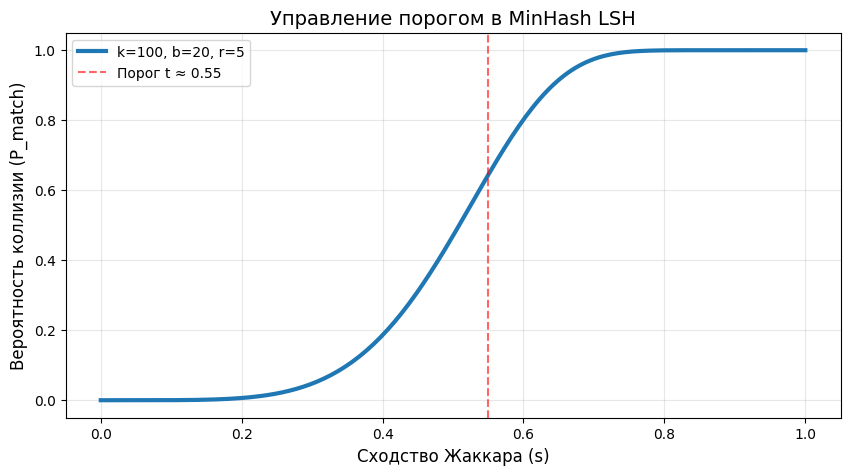

interactive(children=(IntSlider(value=100, description='k', max=1000, min=10, step=10), IntSlider(value=20, de…

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def plot_lsh_curve(k=100, b=20):
    if k % b != 0:
        print(f"Ошибка: k ({k}) должно делиться на b ({b}) нацело!")
        return
    
    r = k // b
    s = np.linspace(0, 1, 200)
    p = 1 - (1 - s**r)**b
    t = (1/b)**(1/r)
    
    plt.figure(figsize=(10, 5))
    plt.plot(s, p, lw=3, label=f'k={k}, b={b}, r={r}')
    plt.axvline(t, color='red', linestyle='--', alpha=0.6, label=f'Порог t ≈ {t:.2f}')
    
    plt.title('Управление порогом в MinHash LSH', fontsize=14)
    plt.xlabel('Сходство Жаккара (s)', fontsize=12)
    plt.ylabel('Вероятность коллизии (P_match)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

interact(plot_lsh_curve, 
         k=IntSlider(min=10, max=1000, step=10, value=100), 
         b=IntSlider(min=1, max=100, step=1, value=20));

In [5]:
!pip3 install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 8.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]3 [ipywidgets]

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


## Конкретные методы (классические)

Ниже список практических подходов. Предположим, сравниваются описания документов A и B. Веротность коллизии их хэшей $h(A)=h(B)$ должна выражаться через расстояние между ними $R$, или что тоже самое, близость $1 - R$. Метод LSH задает, относительно какого расстояния мы используем и, соотвественно, как хэш его моделирует

### <u>Bit sampling</u>

Самый простой метод. Выбираем случайное подмножество фичей и сравниваемся только по ним

Метод моделирует расстояние Хэмминга между двумя бинарными векторами = число различающихся бит. 
Как работает: для случайно выбранной координаты $i \in {1, ..., d}$ полагаем $h_i(x) = x_i$. 

Вероятность коллизии выражается через приближенное расстояние так:
$$\mathbb{P}[ h_i(x) = h_i(y) ] = 1 − \frac{\text{R}(x, y)}{d} = \frac{R - d}{d} = \frac{|\text{совпадающих токенов}|}{|\text{всего токенов}|}$$

При $d \rightarrow N$ 

Какой $\rho$<br>
$p₁ = 1 − R/d$, $p₂ = 1 − cR/d$, и стандартные оценки дают $ρ ≤ 1/c$. То есть $(R, cR)$-NN для Хэмминга решается за $O(n^{1/c})$ времени запроса.

### <u>MinHash</u>

Моделируется сходство Жаккара $R=J(A, B) = \frac{|A ∩ B|}{|A ∪ B|}$. Для случайной перестановки π на U полагаем

$h_π(A) = \arg \min {a \in A} π(a)$

Интерпретация: начинаем сравнивать измерения (наличие токенов) двух документов в случайном порядке, на каком шаге совпало, это и есть значение хэш-бита

<img src="img/minhash.png" width=500>

Данная конструкция хэша определяет вероятность коллизии как $Pr[ h_π(A) = h_π(B) ] = J(A, B)$. Действительно, если мы перемешиваем перестановкой $\pi$ множество токенов A ∪ B, то минимум на множестве одинаково вероятно достигается в любом из его элементов; минимумы по A и по B совпадают тогда и только тогда, когда этот элемент лежит в числе общих $A ∩ B$, что происходит с вероятностью $|A ∩ B| / |A ∪ B|$ (см иллюстрацию). А это и есть близость Жаккара

MinHash — основа классической схемы «bands and rows» для дедупликации документов: документ разбивается на k-граммы (шинглы), вычисляется сигнатура из m минхешей, сигнатура нарезается на b блоков по r минхешей; LSH-таблицы строятся на блоках. Параметры b и r настраивают порог сходства, выше которого документы попадают в кандидаты.

### <u>SimHash</u>

Моделируется косинусная близость: $R=cos \theta(x, y)$. То есть расстояние определено с точностью до масштаба, длина вектора описания не имеет значение, главное угол

Моделируем семейством случайных гиперплоскостей $(r,x)$, проходящих через начало координат, где $r ~ N(0, I_d)$. 

Хэш - в какую полуплоскость попадает документ, то есть знак<br>
$h_r(x) = sign( ⟨r, x⟩ ) ∈ \{ −1, +1\}$

В этой парадигме вероятность коллизии равна (свойство Гёман–Уильямсон):

$Pr[ h_r(x) ≠ h_r(y) ] = θ(x, y) / π$

$Pr[ h_r(x) = h_r(y) ] = 1 − θ(x, y) / π$

Геометрически: гиперплоскость с нормалью r делит пространство пополам; точки попадают в разные полупространства тогда и только тогда, когда r лежит в «двойном клине» между x и y, объёмная доля которого — это в точности θ/π. Реализация сводится к k случайным проекциям и взятию знака — k бит на точку.

__Практическая реализация:__<br>
- применяем хэш-функцию MD5 к каждому токену (это моделирует k-бит)
- переводим в $(-1,1)$
- суммируем по документу
- делаем квантизацию до знака $(-1,1)$

### <u>p-stable LSH</u>

Приближает расстояние $L_p$ при $p \in (0, 2]$

$h_{a, b, w}(x) = ⌊ ( ⟨a, x⟩ + b ) / w ⌋$

Словами:<br>
делаем проекцию документа на случайное направление $a$ со смещением $b$, делим на коэффициент $w$ (для получения нужного масштаба) и берем от этого целую часть. То есть в отличие от random hyperplanes тут режем прищзнаковое простарнство не пополам, а на полосы и хэш тут целочисленный

Гиперпараметр $w$ - это ширина сетки. Чем он шире, тем больше вероятность коллизии. $a$ берется из $N(0,1)$, $b$ из $U[-1,1]$

Коллизия = попадание точек в одну полосу

Почему нормальное $N(0,1)$?<br>
Мы хотим чтобы распределение зависело только от расстония между точками и больше не от чего. Такое свойство может обеспечить только p-стабильные распределения.

Вообще p-стабильных распределений бесконечно много, но аналитических всего несколько:
- для метрики с p=2: нормальное
- для метрики с p=1: распределение Коши

Что такое p-стабильность<br>
Пусть компоненты вектора $\vec{a}$ сэмплируются независимо из некоторого p-стабильного распределения $D$, тогда проекция (скалярного произведения) любого вектора $\vec{v}$ на вектор $\vec{a}$ имеет то же распределение $D$, но масштабированное на $L_p$-норму этого вектора $v$ (т.е. на $||v||_p$)

Почему проекционный вектор нормали $\vec{a}$ берут из $N(0,1)$ а не из равномерного $U(-1,1)$?<br>
Потому что только тогда получается по настоящему равномерное распределение угла $\theta$. Вот иллюстрация, где это хорошо видно. Мы генерируем случайные векторы (отдельно каждый компонент) двумя способами. Под графиками - гистограмма значений угла получаемых векторов. Видно, что во втором случае на диагоналях пики (точек на этом направлении больше)

<img src="img/lsh_normal_uniform.jpg" width=500>

Иллюстрирующая метафора:<br>
мы разбрасываем на песке несколько ракушек, берем одностороннюю решетку, k раз её просаем на песок, каждый раз случайно поворачивая и чуть сдвигая. Тогда коллизия - ситуация, когда две ракушки оказались в одном отпечатке. Далее делаем амплификацию - стираем линии и повторяем процедуру несколько раз. Смотрим, чтобы хотя бы на одной итерации две точки оказывались в одном секторе



### <u>LSH Forest</u>

В качестве одной хэш-функции используется случайное дерево их рандомных разбиений. Реализовано через Trie-дерево, допустим есть k-битный код 001011010, тогда строится бинарное дерево и каждый документ кладется в листовую вершину. 

То есть в роли хэш-функции у нас выступает бинарное дерево с k-мерными разбиениями.

### Реализации

Теоретически оптимальные значения гиперпараметров k и L подбираются по формулам 
- $k = log_{1/p_2} n$
- $L = n^\theta$.

Гарантии асимптотические: ожидаемое время запроса $O(n^ρ)$, память $O(n^{1+ρ})$, вероятность успеха константа. Полная задача NN сводится к $O(log n)$ (R, cR)-структур для геометрически растущих R, что добавляет log-фактор к памяти и времени.

Практический алгоритм. В реальных библиотеках (E²LSH, FALCONN, datasketch, NearPy) гарантии не доказываются, а измеряются. Вместо вывода k и L из теории они подбираются перебором на валидационной выборке: цель — баланс между recall (долей корректно найденных соседей) и средним числом проверок-кандидатов на запрос. Несколько практических расширений, отсутствующих в теоретической версии:

- Композитные проекции. Для L_2 вместо одного случайного вектора используют блок из M проекций сразу и формируют сигнатуру как M-мерный вектор бинов, конкатенированный в k групп. Это уменьшает дисперсию.
- Multi-probe LSH. Вместо просмотра только корзины g(q) просматривают и соседние корзины — те, что отличаются в одной координате на ±1, затем в двух и так далее. Это позволяет в разы уменьшить L (часто с десятков до единиц) при сохранении recall и кардинально экономит память.
- LSH Forest. Вместо фиксированного k используется префиксное дерево над базовыми хешами; глубина просмотра адаптивно подбирается на каждый запрос.
- Хранилище. Хеш-таблица обычно реализуется как открытая адресация по 32- или 64-битному хешу сигнатуры, а не по самой k-мерной сигнатуре. Сами вектора хранятся отдельно — узким массивом float32 в памяти или на диске — и подгружаются на этапе финальной проверки расстояния.

В современных продакшен-системах LSH часто проигрывает HNSW и графовым индексам по recall@k при той же памяти, но остаётся базовым выбором при потоковых обновлениях, при необходимости теоретических гарантий и при экстремально высокой размерности или разреженности входа.


## Примеры использования

Дедупликация веб-страниц. AltaVista (1997, MinHash) и затем Google использовали LSH для нахождения почти-дубликатов в индексах из миллиардов документов. Документ → шинглы → MinHash-сигнатура → LSH-таблица.

Обнаружение плагиата и спама. Аналогично, на уровне абзацев и предложений.

Рекомендательные системы. Похожие пользователи или похожие айтемы (по бинарным взаимодействиям, по латентным эмбеддингам) находятся LSH-ом по Жаккару или косинусу. Используется в потоковых сервисах и e-commerce для генерации кандидатов перед более точным переранжированием.

Поиск изображений по сходству. SIFT/ORB-дескрипторы либо нейросетевые эмбеддинги индексируются LSH (обычно SimHash или p-stable). Применялось в сервисах обратного поиска картинок, в детекции дубликатов и почти-дубликатов в фотобанках.

Биоинформатика. Поиск похожих ДНК/РНК/белковых последовательностей. Инструменты вроде Mash и MASH-Sketch оценивают расстояние между геномами по MinHash-сигнатурам k-меров и позволяют сравнивать тысячи геномов за минуты.

Безопасность и анализ вредоносного ПО. Поиск похожих бинарных файлов, fuzzy hashing (ssdeep, sdhash) — концептуальные родственники LSH; кластеризация семейств malware.

Retrieval-augmented generation и предварительная фильтрация эмбеддингов. На промежуточных стадиях retrieval, особенно на CPU и при потоковом обновлении базы, LSH остаётся конкурентным как первая ступень фильтра перед точным переранжированием.

## Резюме

LSH — это семейство хеш-функций, спроектированных так, чтобы вероятность коллизии монотонно зависела от расстояния между объектами. Композиция k функций внутри одной таблицы и L независимых таблиц позволяет одновременно контролировать вероятность пропуска истинного соседа и количество ложных кандидатов. При выборе k = log_{1/p₂} n и L = n^ρ алгоритм даёт сублинейный поиск приближённого ближайшего соседа: ожидаемое время запроса O(n^ρ), память O(n^{1+ρ}), где ρ = log(1/p₁) / log(1/p₂) и обычно ρ < 1.

LSH-семейства известны для большинства практически интересных метрик: bit sampling для Хэмминга, MinHash для Жаккара, SimHash для косинуса, p-stable для L_p. На практике параметры k и L подбираются эмпирически, а к стандартной схеме добавляются multi-probe и адаптивные варианты вроде LSH Forest. Несмотря на конкуренцию со стороны HNSW и обучаемых хеш-методов, LSH сохраняет роль теоретически прозрачного, хорошо параллелизуемого и устойчивого к потоковым обновлениям инструмента приближённого поиска ближайших соседей.